# portfolio Version Workflow

1. Problem Statement

2. Dataset Overview

3. Data Cleaning

4. Exploratory Data Analysis

5. Text Preprocessing

6. TF-IDF Vectorization

7. Combined Feature Engineering

8. Multi-Model Training:

        i. Multinomial Naive Bayes
        ii. Logistic Regression
        iii. Random Forest
        iv. XGBoost

9. Hyperparameter Tuning

10. Evaluation

       i. Accuracy
        ii. Precision
        iii. Recall
        iv. F1-score
        v. Confusion Matrix

11. SHAP

12. Build Streamlit App

# 1. Problem statement

 Spam Detection Using Machine Learning and NLP:

This project builds a machine learning model to classify SMS messages as either spam or ham. 

The dataset contains 5,574 labelled SMS messages. 

The project applies text preprocessing, TF-IDF vectorisation, machine learning classification, model evaluation, and deployment using Streamlit.


# 2. Dataset Overview

In [1]:
# Import libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re
import string

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

import joblib



In [2]:
!pip install wordcloud

In [3]:
# import dataset
df = pd.read_csv('data/spam.csv', encoding='latin-1')
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [4]:
df.shape

(5572, 5)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


# 3. Data Cleaning

In [6]:
# check missing data
df.isnull().sum()

v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

In [7]:
# Drop Empty Column
df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'],
        inplace=True)

In [8]:
# Rename column
df.columns = ['label', 'message']

In [9]:
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [10]:
# check Duplicate
df.duplicated().sum()

np.int64(403)

In [11]:
df.drop_duplicates(inplace=True)

In [12]:
df.shape

(5169, 2)

In [13]:
# Check Class Distribution
df['label'].value_counts()

label
ham     4516
spam     653
Name: count, dtype: int64

The dataset is moderately imbalanced, with legitimate (ham) messages significantly outnumbering spam messages. This reflects real-world messaging environments where spam typically represents a smaller proportion of total communications.

In [14]:
# Create Target Variable
df['target'] = df['label'].map({
    'ham':0,
    'spam':1
})

In [15]:
df.head()

,label,message,target
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


# 4. Exploratory Data Analysis

In [16]:
#  Feature Engineering

# Character count
df['char_count'] = df['message'].apply(len)

# Word count
df['word_count'] = df['message'].apply(
    lambda x: len(x.split())
)

# Exclamation marks
df['exclamation_count'] = df['message'].apply(
    lambda x: x.count('!')
)

# Number of digits
df['digit_count'] = df['message'].apply(
    lambda x: sum(c.isdigit() for c in x)
)

# Uppercase letters
df['uppercase_count'] = df['message'].apply(
    lambda x: sum(c.isupper() for c in x)
)


In [17]:
# verify
df[['char_count',
    'word_count',
    'exclamation_count',
    'digit_count',
    'uppercase_count']].describe()

,char_count,word_count,exclamation_count,digit_count,uppercase_count
count,5169.000000,5169.000000,5169.000000,5169.000000,5169.000000
mean,78.977945,15.340685,0.240279,2.205069,5.337009
std,58.236293,11.068488,0.672257,6.025241,11.155901
min,2.000000,1.000000,0.000000,0.000000,0.000000
25%,36.000000,7.000000,0.000000,0.000000,1.000000
50%,60.000000,12.000000,0.000000,0.000000,2.000000
75%,117.000000,22.000000,0.000000,1.000000,4.000000
max,910.000000,171.000000,11.000000,47.000000,128.000000


The dataset appears highly skewed:

Most messages are short and simple.

A small number of messages are extremely long.

Most messages contain no exclamation marks.

Most messages contain no numbers.

Most messages contain very few uppercase letters.

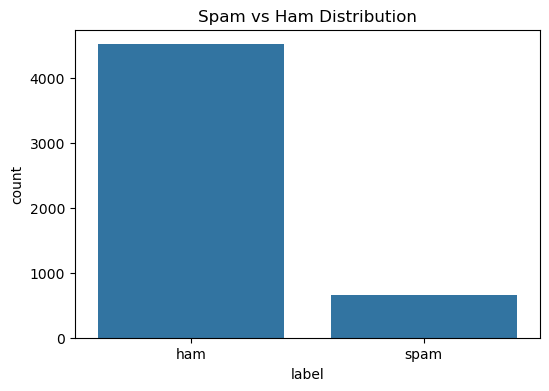

In [18]:
# Visualization
# 1. class distribution

plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x='label'
)

plt.title('Spam vs Ham Distribution')
plt.show()

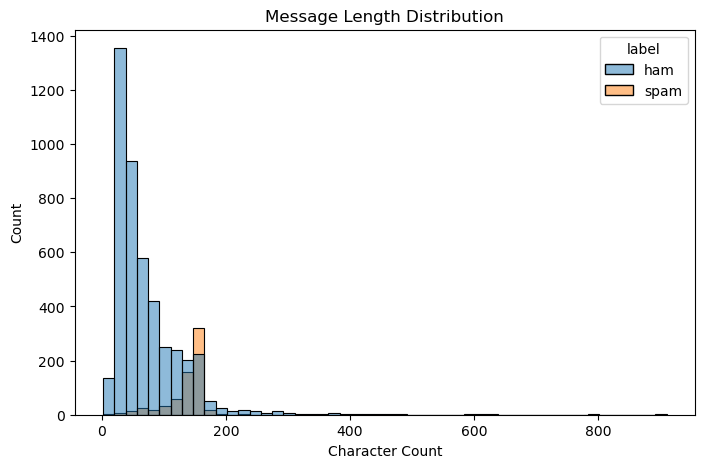

In [19]:
# 2. Message length Distribution: Do spam messages tend to be longer?
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='char_count',
    hue='label',
    bins=50
)

plt.title('Message Length Distribution')
plt.xlabel('Character Count')
plt.show()

In [20]:
# 3.Spam Percentage
spam_pct = round(
    (df['label'].value_counts(normalize=True)*100),2
)

spam_pct

label
ham     87.37
spam    12.63
Name: proportion, dtype: float64

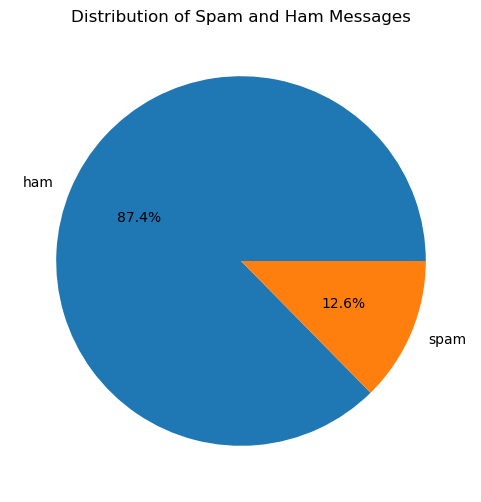

In [21]:
plt.figure(figsize=(6,6))

df['label'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.ylabel('')
plt.title('Distribution of Spam and Ham Messages')
plt.show()

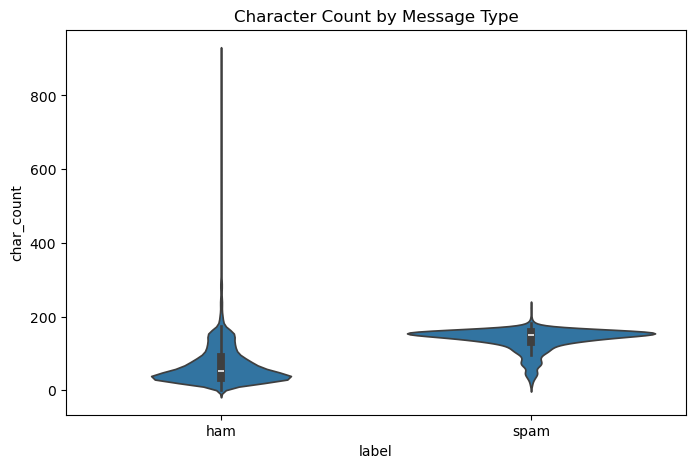

In [22]:
# 4. Violin plot(length Histogram: Are spam messages significantly longer than ham messages?
plt.figure(figsize=(8,5))

sns.violinplot(
    data=df,
    x='label',
    y='char_count'
)

plt.title('Character Count by Message Type')
plt.show()

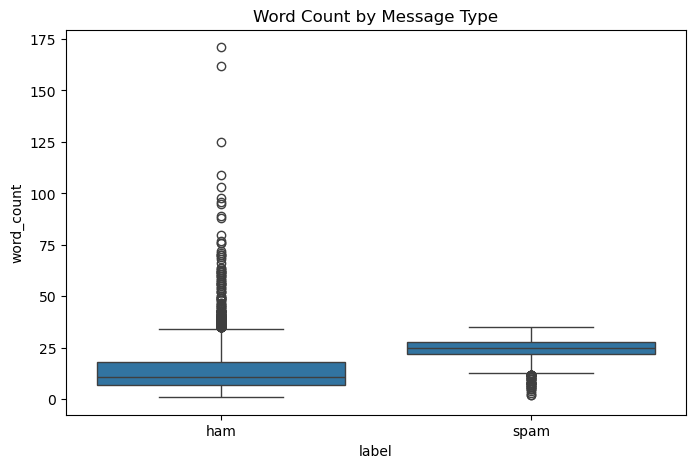

In [23]:
# 5. Word count Comparison
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='label',
    y='word_count'
)

plt.title('Word Count by Message Type')
plt.show()

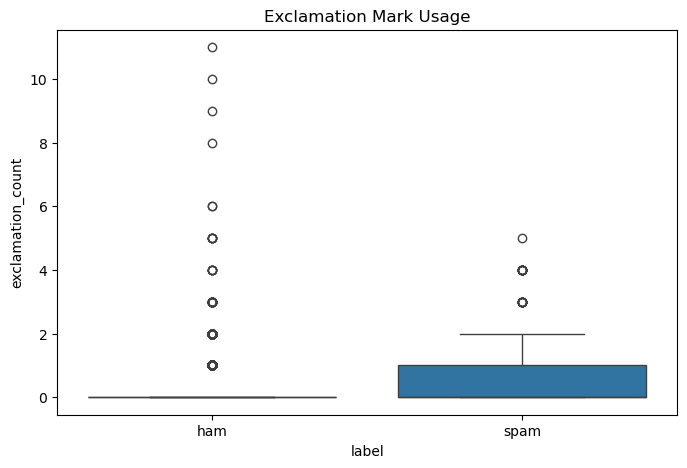

In [24]:
# 6.Exclamation Marks: Do spam messages use more urgency and promotional language?

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='label',
    y='exclamation_count'
)

plt.title('Exclamation Mark Usage')
plt.show()

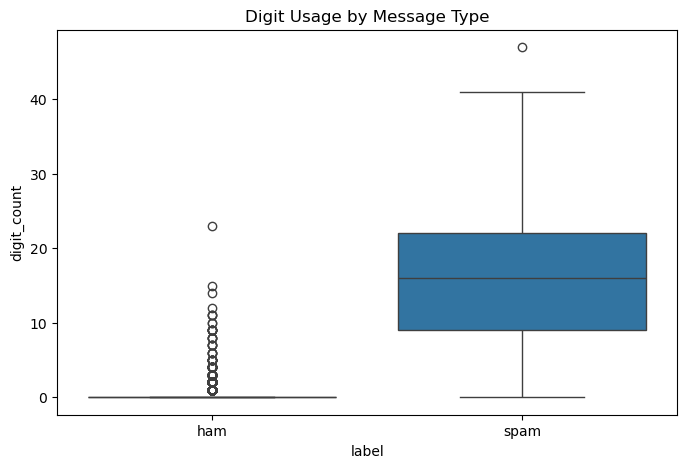

In [25]:
# 7.Numbers Used: Do spam messages contain more phone numbers, codes and monetary values?

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='label',
    y='digit_count'
)

plt.title('Digit Usage by Message Type')
plt.show()

<Axes: >

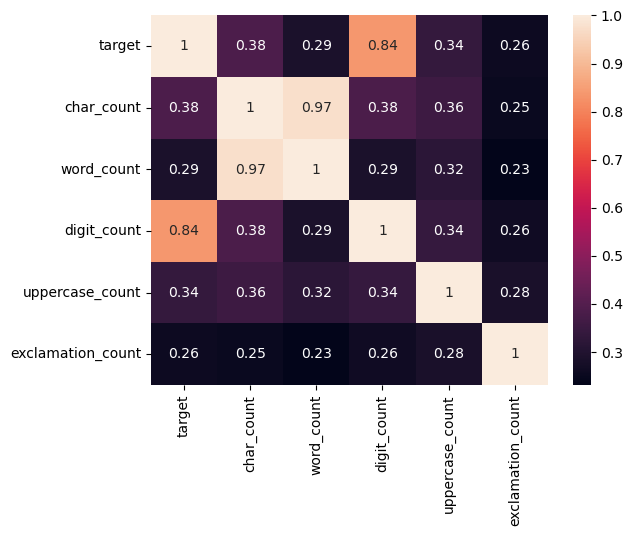

In [26]:
# 8.Correlation Heatmap showing feature relationship
sns.heatmap(
    df[['target',
        'char_count',
        'word_count',
        'digit_count',
        'uppercase_count',
        'exclamation_count']].corr(),
    annot=True
)

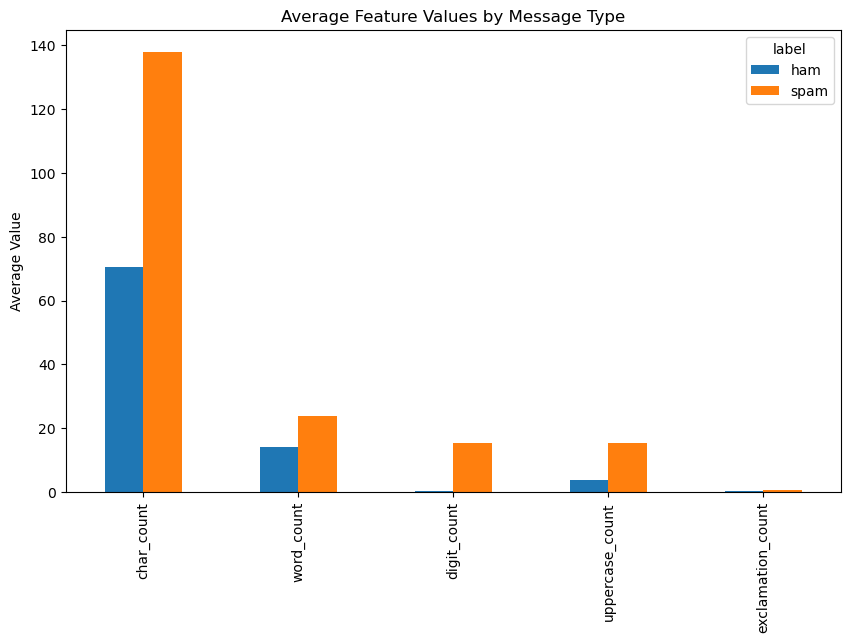

In [27]:
# 9.Mean Feature Comparison
feature_summary = df.groupby('label')[
    ['char_count',
     'word_count',
     'digit_count',
     'uppercase_count',
     'exclamation_count']
].mean()

feature_summary.T.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Average Feature Values by Message Type')
plt.ylabel('Average Value')
plt.show()

In [28]:
from wordcloud import WordCloud

In [29]:
# create Ham text
ham_text = " ".join(
    df[df['label'] == 'ham']['message']
)

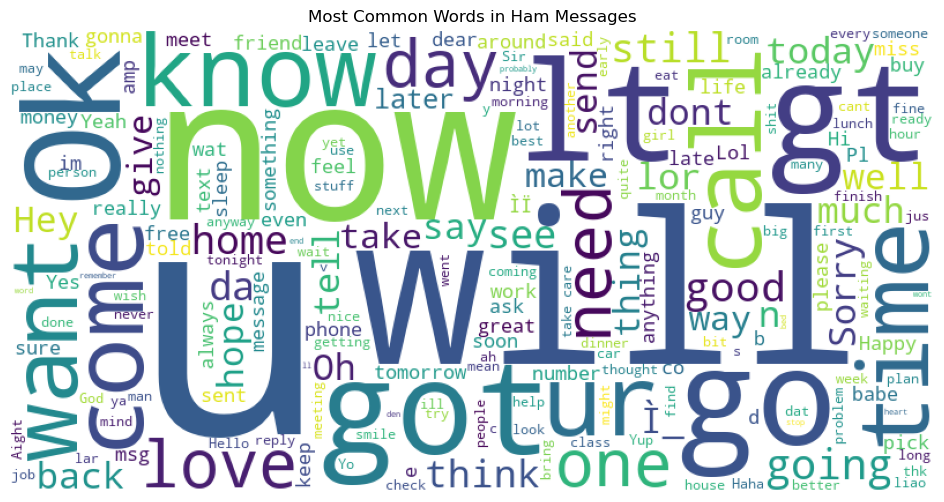

In [30]:

wc = WordCloud(
    width=800,
    height=400,
    background_color='white'
)

ham_wc = wc.generate(ham_text)

plt.figure(figsize=(12,6))
plt.imshow(ham_wc)
plt.axis('off')
plt.title('Most Common Words in Ham Messages')
plt.show()

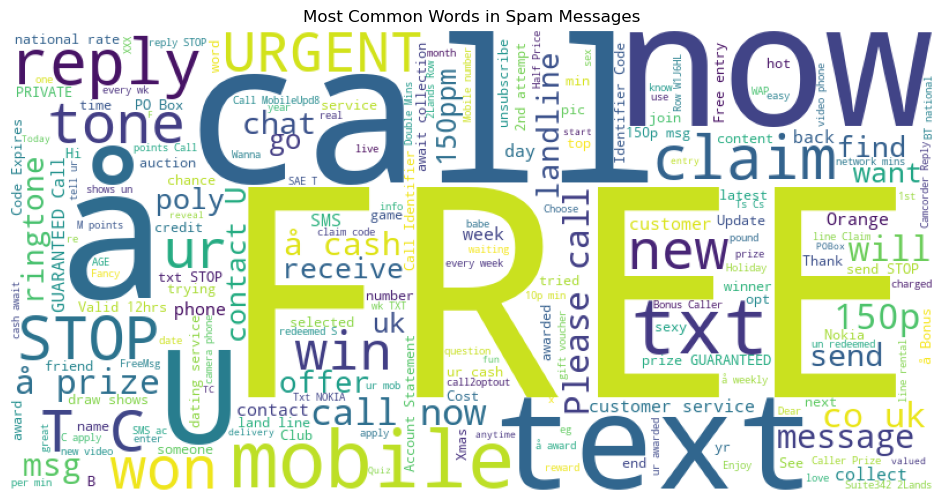

In [31]:
# Spam Word Cloud
spam_text = " ".join(
    df[df['label'] == 'spam']['message']
)

spam_wc = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(spam_text)

plt.figure(figsize=(12,6))
plt.imshow(spam_wc)
plt.axis('off')
plt.title('Most Common Words in Spam Messages')
plt.show()

In [32]:
from collections import Counter
from nltk.corpus import stopwords
import re

stop_words = set(stopwords.words('english'))

spam_words = []

for msg in df[df['label'] == 'spam']['message']:
    words = re.findall(r'\b[a-zA-Z]+\b', msg.lower())
    
    for word in words:
        if word not in stop_words:
            spam_words.append(word)

spam_counter = Counter(spam_words)

spam_top20 = pd.DataFrame(
    spam_counter.most_common(20),
    columns=['Word', 'Frequency']
)

spam_top20

,Word,Frequency
0,call,309
1,free,195
2,u,147
3,txt,134
4,ur,119
5,mobile,109
6,stop,109
7,text,108
8,claim,96
9,reply,96


In [33]:
# Top 20 Ham words
ham_words = []

for msg in df[df['label'] == 'ham']['message']:
    words = re.findall(r'\b[a-zA-Z]+\b', msg.lower())
    
    for word in words:
        if word not in stop_words:
            ham_words.append(word)

ham_counter = Counter(ham_words)

ham_top20 = pd.DataFrame(
    ham_counter.most_common(20),
    columns=['Word', 'Frequency']
)

ham_top20

,Word,Frequency
0,u,915
1,get,297
2,gt,288
3,lt,287
4,ok,255
5,go,241
6,got,226
7,know,225
8,like,222
9,good,215


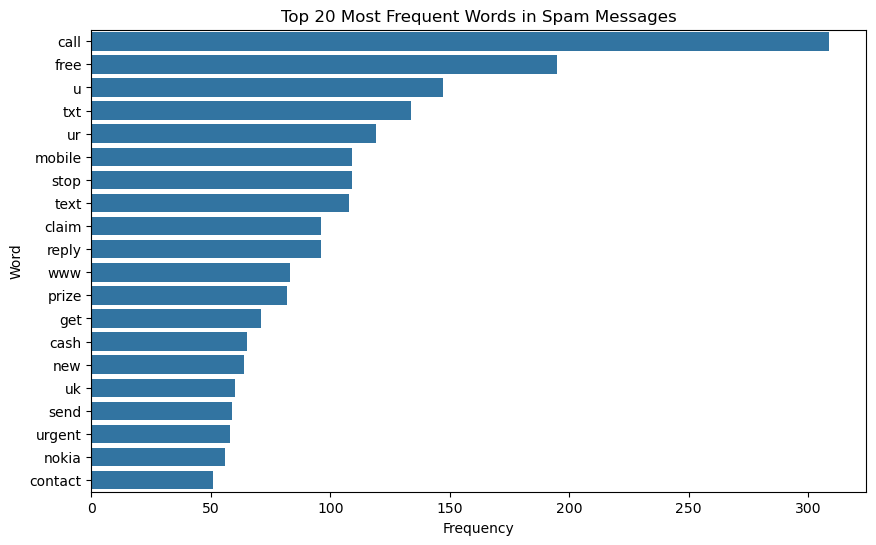

In [34]:
# visualize Top 20 Spam Word
plt.figure(figsize=(10,6))

sns.barplot(
    data=spam_top20,
    x='Frequency',
    y='Word'
)

plt.title('Top 20 Most Frequent Words in Spam Messages')
plt.show()

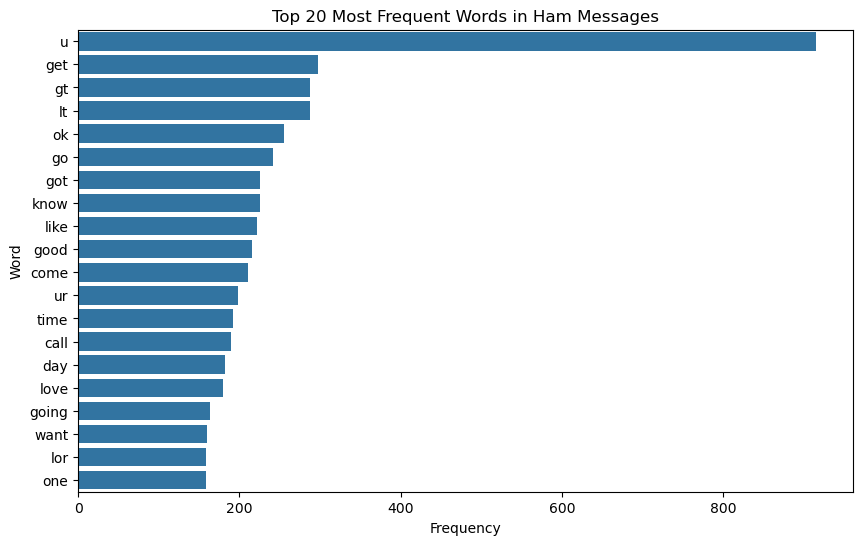

In [35]:
# Visualize Top 20 Ham words
plt.figure(figsize=(10,6))

sns.barplot(
    data=ham_top20,
    x='Frequency',
    y='Word'
)

plt.title('Top 20 Most Frequent Words in Ham Messages')
plt.show()

Analysis of the most frequent words reveals clear linguistic differences between spam and ham messages. Ham messages primarily contain conversational and socially oriented terms such as "ok", "love", and "time", reflecting everyday communication. In contrast, spam messages are dominated by promotional and action-oriented terms including "free", "claim", "cash", "prize", and "urgent". These patterns suggest that textual content contains strong predictive signals that can be leveraged by machine learning models for spam classification.

In [36]:
import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    words = text.split()

    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [37]:
df['processed_text'] = df['message'].apply(preprocess_text)

In [38]:
# verify
df[['message', 'processed_text']].head()

,message,processed_text
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,"Nah I don't think he goes to usf, he lives aro...",nah think go usf life around though


In [39]:
# Generate Spam Bigram

from sklearn.feature_extraction.text import CountVectorizer

spam_corpus = df[df['label'] == 'spam']['processed_text']

vectorizer = CountVectorizer(
    ngram_range=(2, 2),
    stop_words='english'
)

X_bigram = vectorizer.fit_transform(spam_corpus)

In [40]:
# create frequencies
bigram_counts = X_bigram.sum(axis=0)

bigram_freq = [
    (word, bigram_counts[0, idx])
    for word, idx in vectorizer.vocabulary_.items()
]

bigram_freq = sorted(
    bigram_freq,
    key=lambda x: x[1],
    reverse=True
)

In [41]:
# Top 20 spam messages
bigram_df = pd.DataFrame(
    bigram_freq[:20],
    columns=['Bigram','Frequency']
)

bigram_df

,Bigram,Frequency
0,po box,24
1,customer service,22
2,prize guaranteed,20
3,valid hr,18
4,send stop,18
5,urgent mobile,17
6,national rate,17
7,selected receive,16
8,txt stop,16
9,land line,16


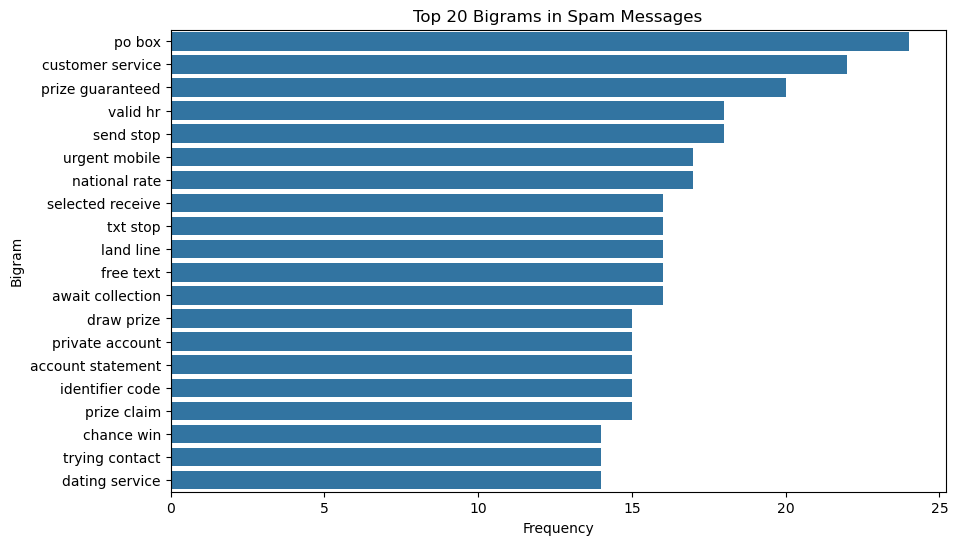

In [42]:
# Visualize spam messages
plt.figure(figsize=(10,6))

sns.barplot(
    data=bigram_df,
    x='Frequency',
    y='Bigram'
)

plt.title('Top 20 Bigrams in Spam Messages')
plt.show()

# 5. Text preprocessing

In [43]:
# check Transformation

df[['message', 'processed_text']].sample(10)

,message,processed_text
1296,Sure! I am driving but will reach my destinati...,sure driving reach destination soon
4747,The beauty of life is in next second.. which h...,beauty life next second hide thousand secret w...
2314,Also that chat was awesome but don't make it r...,also chat awesome make regular unless see person
4845,Pls help me tell Ashley that i cant find her n...,pls help tell ashley cant find number oh
2057,"Nothing, i got msg frm tht unknown no..",nothing got msg frm tht unknown
4927,Just hopeing that wasnÛ÷t too pissed up to re...,hopeing pissed remember gone sister something
1282,Ever green quote ever told by Jerry in cartoon...,ever green quote ever told jerry cartoon perso...
450,hanks lotsly!,hank lotsly
4723,FREE GAME. Get Rayman Golf 4 FREE from the O2 ...,free game get rayman golf free game arcade st ...
3081,"And very importantly, all we discuss is betwee...",importantly discus u


# 6. TF-IDF Vectorization

In [44]:
# Create TF-IDF Features: Using unigrams + bigrams.

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)
)

X_text = tfidf.fit_transform(
    df['processed_text']
)

In [45]:
X_text.shape

(5169, 5000)

In [46]:
# Inspect Vocabulary
len(tfidf.vocabulary_)

5000

In [47]:
# Top features

feature_names = tfidf.get_feature_names_out()

feature_names[:50]

array(['aah', 'aathi', 'abi', 'abiola', 'able', 'able get', 'abt', 'abta',
       'abta complimentary', 'ac', 'acc', 'accept', 'access', 'accident',
       'accidentally', 'accordingly', 'account', 'account detail',
       'account statement', 'ache', 'across', 'across sea', 'action',
       'activate', 'actually', 'ad', 'add', 'added', 'addie', 'address',
       'admirer', 'admirer looking', 'adore', 'adult', 'advance',
       'advice', 'ae', 'affair', 'afraid', 'aft', 'aft ur', 'afternoon',
       'afternoon love', 'aftr', 'age', 'age perwksub', 'ago', 'ah',
       'aha', 'ahead'], dtype=object)

# 7. Combine Engineered Features

In [48]:
engineered_features = df[
    [
        'char_count',
        'word_count',
        'digit_count',
        'uppercase_count',
        'exclamation_count'
    ]
]

In [49]:
# Combine Text + Engineered Features
from scipy.sparse import hstack

X = hstack([
    X_text,
    engineered_features.values
])

# Target
y = df['target']

#check
X.shape

(5169, 5005)

# 8. Multi-model training

In [50]:
# Create Stratified k-Fold
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [51]:
# create Evaluation Function

from sklearn.model_selection import cross_validate
import pandas as pd

def evaluate_model(model, X, y):

    scoring = {
        'accuracy':'accuracy',
        'precision':'precision',
        'recall':'recall',
        'f1':'f1'
    }

    scores = cross_validate(
        model,
        X,
        y,
        cv=skf,
        scoring=scoring,
        n_jobs=-1
    )

    return {
        'Accuracy': scores['test_accuracy'].mean(),
        'Precision': scores['test_precision'].mean(),
        'Recall': scores['test_recall'].mean(),
        'F1': scores['test_f1'].mean()
    }

In [52]:
# Build Models
# Naive Bayes
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

In [53]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

In [54]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

In [55]:
# XGBoost
from xgboost import XGBClassifier

scale_pos_weight = (
    len(y[y==0]) /
    len(y[y==1])
)

scale_pos_weight

6.915773353751915

In [56]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42
)

In [57]:
# Evaluate Models

results = []

models = {
    'Naive Bayes': nb_model,
    'Logistic Regression': lr_model,
    'Random Forest': rf_model,
    'XGBoost': xgb_model
}

for name, model in models.items():

    result = evaluate_model(
        model,
        X,
        y
    )

    result['Model'] = name

    results.append(result)

In [58]:
# Create Comparison Table

results_df = pd.DataFrame(results)

results_df = results_df[
    ['Model',
     'Accuracy',
     'Precision',
     'Recall',
     'F1']
]

results_df.sort_values(
    by='F1',
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1
3,XGBoost,0.986458,0.953725,0.938732,0.945979
2,Random Forest,0.986845,0.996580,0.898931,0.944897
1,Logistic Regression,0.980267,0.918212,0.926494,0.922083
0,Naive Bayes,0.954149,0.800712,0.850006,0.824043


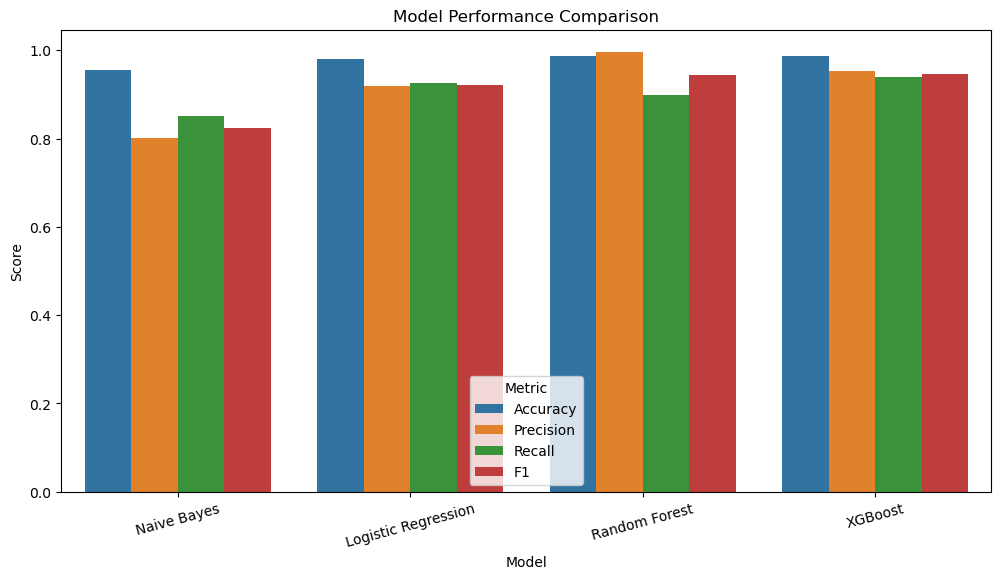

In [59]:
# Visual Comparison
results_melted = results_df.melt(
    id_vars='Model',
    var_name='Metric',
    value_name='Score'
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=results_melted,
    x='Model',
    y='Score',
    hue='Metric'
)

plt.title('Model Performance Comparison')
plt.xticks(rotation=15)

plt.savefig(
    "visuals/Model Performance Comparison.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

# 9. Hyperparameter Tuning

In [60]:
# Retrain the best model, XGBoost

X = hstack([
    X_text,
    engineered_features.values
])

y = df['target']

In [61]:
# Calculate class imbalance weight
scale_pos_weight = len(y[y == 0]) / len(y[y == 1])

scale_pos_weight

6.915773353751915

In [62]:
# Base XGBoost Model
from xgboost import XGBClassifier

xgb_base = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1
)

In [63]:
# Hyperparameter Grid
param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 4, 5, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.2]
}

In [64]:
# Randomized search
from sklearn.model_selection import RandomizedSearchCV

xgb_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_grid,
    n_iter=30,
    scoring='f1',
    cv=skf,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

xgb_search.fit(X, y)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric='logloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None...
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=-1,
                                           num_parallel_tree=None, ...),
                   n_iter=30, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.8, 0.9, 1.0],
                                        'gamma': [0, 0.1, 0.2],
                                        'learning_rate': [0.01, 0.05, 0.1, 0.2],
                                        'max_depth': [3, 4, 5, 6, 8],
                                        'min_child_weight': [1, 3, 5],
                                        'n_estimators': [100, 200, 300, 500],
                                        'subsample': [0.8, 0.9, 1.0]},
                   random_state=42, scoring='f1', verbose=2)

In [65]:
# Best Parameters
print("Best Parameters:")
print(xgb_search.best_params_)

print("\nBest F1:")
print(xgb_search.best_score_)

Best Parameters:
{'subsample': 0.8, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 6, 'learning_rate': 0.1, 'gamma': 0.2, 'colsample_bytree': 1.0}

Best F1:
0.9474875894654229


In [66]:
# Save Best Model
best_xgb = xgb_search.best_estimator_

# 10. Evaluation

In [67]:
# Final Evaluation
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [68]:
# Trained tuned model
best_xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=1.0, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=0.2,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=1, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=-1,
              num_parallel_tree=None, ...)

In [69]:
# Predictions
y_pred = best_xgb.predict(X_test)

In [70]:
# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 0.9893617021276596
Precision: 0.9411764705882353
Recall   : 0.9770992366412213
F1 Score : 0.9588014981273408


In [71]:
# Classification Report
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99       903
           1       0.94      0.98      0.96       131

    accuracy                           0.99      1034
   macro avg       0.97      0.98      0.98      1034
weighted avg       0.99      0.99      0.99      1034



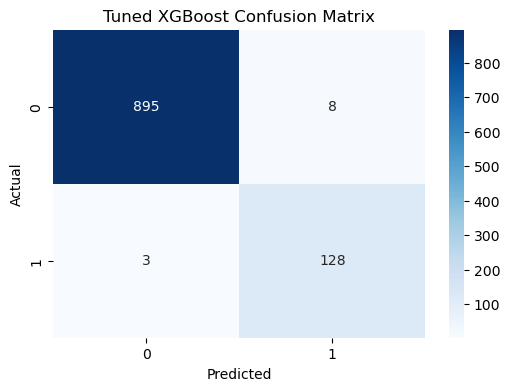

In [72]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Tuned XGBoost Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [73]:
# ROC-AUC
from sklearn.metrics import roc_auc_score

y_prob = best_xgb.predict_proba(X_test)[:,1]

roc_auc = roc_auc_score(
    y_test,
    y_prob
)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.9965424834943741


# 11. SHAP

In [74]:
# install shap
!pip install shap

In [75]:
# Import SHAP
import shap

In [76]:
# Create Explainer

explainer = shap.TreeExplainer(best_xgb)

In [77]:
# Generate SHAP Values
X_sample = X_test[:300]

shap_values = explainer.shap_values(X_sample)

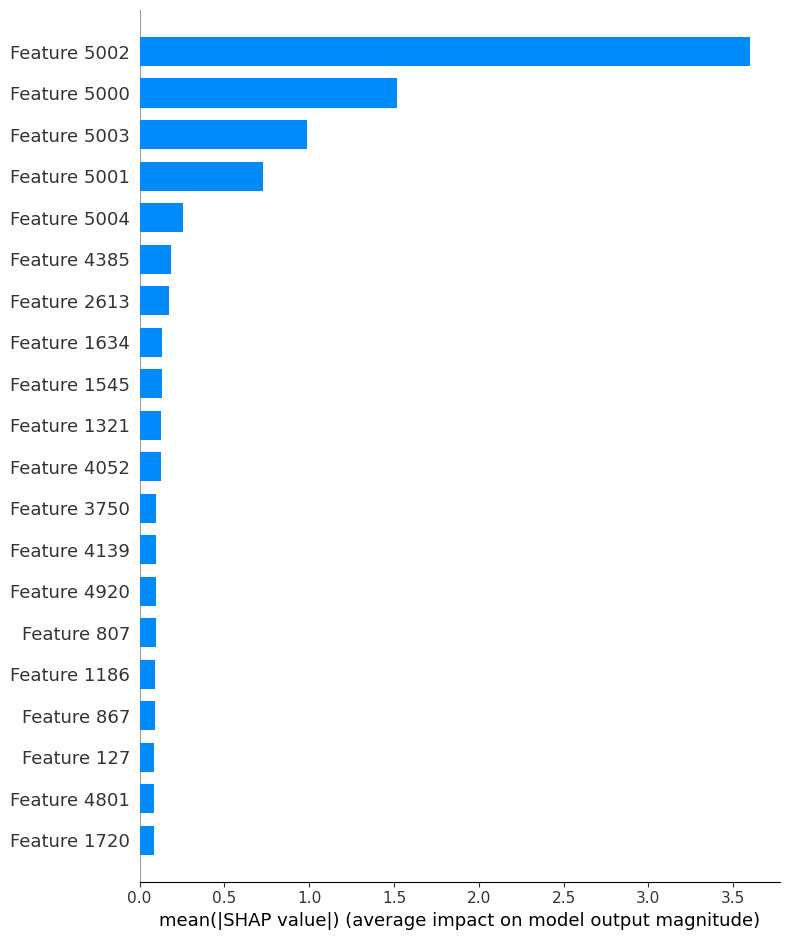

In [78]:
# Global Feature Importance
shap.summary_plot(
    shap_values,
    X_sample,
    plot_type='bar'
)

In [79]:
# Create Feature Names
tfidf_features = tfidf.get_feature_names_out().tolist()

In [80]:
# Engineered feature
engineered_names = [
    'char_count',
    'word_count',
    'digit_count',
    'uppercase_count',
    'exclamation_count'
]

In [81]:
# Combine
feature_names = (
    tfidf_features +
    engineered_names
)

In [82]:
# Verify
len(feature_names)

5005

In [83]:
X.shape[1]

5005

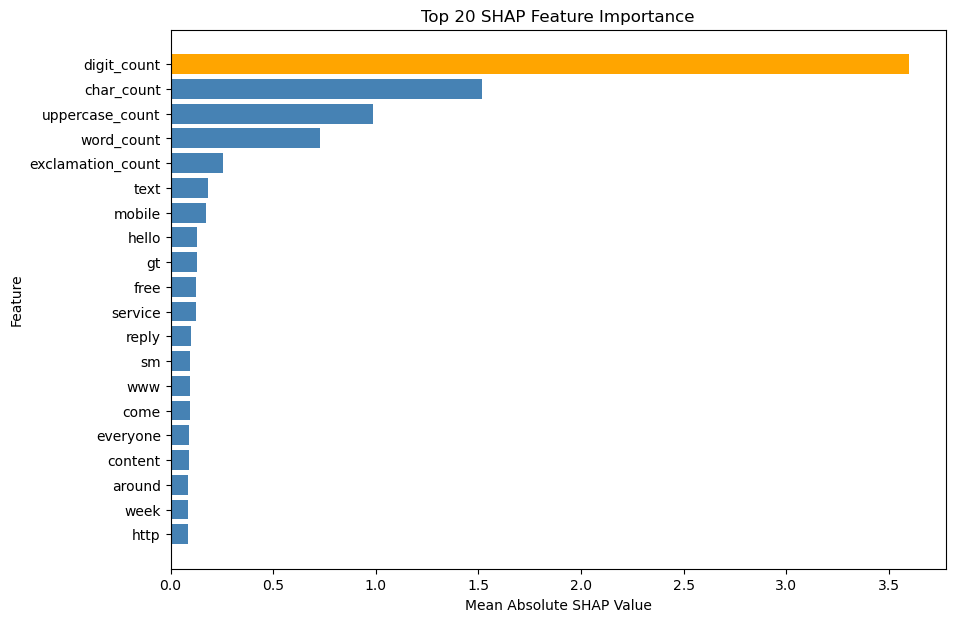

In [84]:
# Shap Bar plot

mean_shap = np.abs(shap_values).mean(axis=0)

shap_importance = pd.DataFrame({
    'Feature': feature_names,
    'Mean_SHAP': mean_shap
}).sort_values(by='Mean_SHAP', ascending=False).head(20)

colors = ['orange' if i == 0 else 'steelblue' for i in range(len(shap_importance))]

plt.figure(figsize=(10, 7))
plt.barh(
    shap_importance['Feature'][::-1],
    shap_importance['Mean_SHAP'][::-1],
    color=colors[::-1]
)

plt.title('Top 20 SHAP Feature Importance')
plt.xlabel('Mean Absolute SHAP Value')
plt.ylabel('Feature')
plt.show()

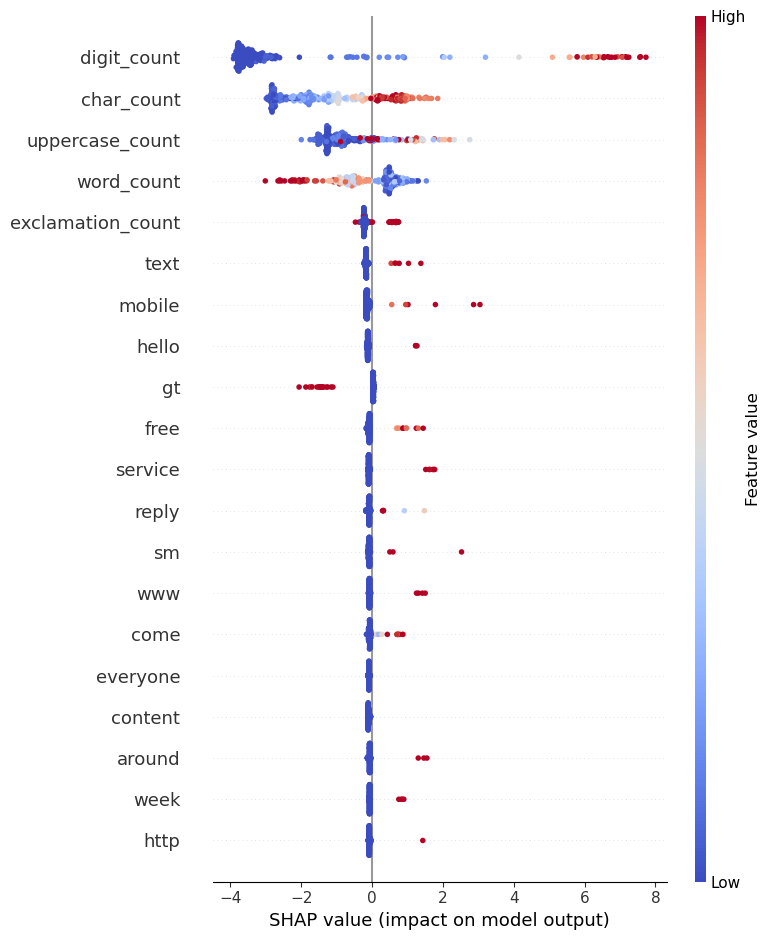

In [85]:
# Shap detailed summmary plot
X_sample_dense = X_sample.toarray()

shap.summary_plot(
    shap_values,
    X_sample_dense,
    feature_names=feature_names,
    cmap='coolwarm'
)

# 12. Save 

In [86]:
# Save Model
import joblib

joblib.dump(
    best_xgb,
    "models/spam_model.pkl"
)

print("Model saved.")

Model saved.


In [87]:
# save TF-IDF Vectotizer
joblib.dump(
    tfidf,
    "models/tfidf_vectorizer.pkl"
)

print("Vectorizer saved.")

Vectorizer saved.


In [88]:
# save SHAP Summary
plt.figure()

shap.summary_plot(
    shap_values,
    X_sample_dense,
    feature_names=feature_names,
    cmap='coolwarm',
    show=False
)

plt.savefig(
    "visuals/shap_summary.png",
    bbox_inches="tight",
    dpi=300
)

plt.close()

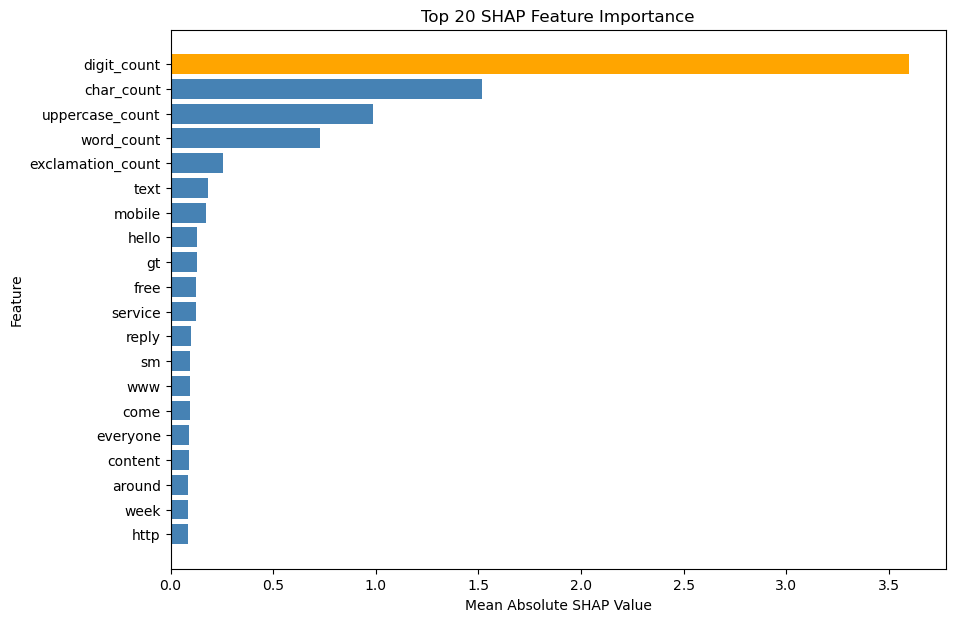

In [89]:
#shap barplot
plt.figure(figsize=(10, 7))

plt.barh(
    shap_importance['Feature'][::-1],
    shap_importance['Mean_SHAP'][::-1],
    color=colors[::-1]
)

plt.title('Top 20 SHAP Feature Importance')
plt.xlabel('Mean Absolute SHAP Value')
plt.ylabel('Feature')

plt.savefig(
    "visuals/shap_bar.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

In [90]:
# Save model and vectorizer
import os
import joblib

os.makedirs("models", exist_ok=True)

joblib.dump(best_xgb, "models/spam_model.pkl")
joblib.dump(tfidf, "models/tfidf_vectorizer.pkl")

print("Model and vectorizer saved successfully.")

Model and vectorizer saved successfully.


In [92]:
import sys

print(sys.executable)

C:\Users\hp\anaconda3\python.exe


In [93]:
get_ipython()

In [94]:
import sys
print(sys.executable)

C:\Users\hp\anaconda3\python.exe


In [95]:
import streamlit
print(streamlit.__version__)

1.45.1


In [96]:
import sys
print(sys.executable)

C:\Users\hp\anaconda3\python.exe


In [ ]:
import sys
import os

os.system(f'"{sys.executable}" -m streamlit run app.py')